# DNF Reporting Model

**Goal**: Identify races that likely don't report DNFs, which would bias our finish time model.

**Approach** (fast and theoretically sound):
1. **Learn distance-DNF relationship** using ONLY races with observed DNFs (clean training data)
   - Fit beta-binomial: `logit(p_dnf) = μ + β × (distance - 50km)` on races with DNF count > 0
   - This gives us: "If a race at distance X reports DNFs, what DNF rate should we expect?"
2. **Compute P(0 DNFs | reporting)** for each race as a **derived quantity**:
   - Use beta-binomial PMF with learned μ, β, κ
   - For races with many attempts but 0 DNFs, this probability is LOW (suspicious!)
   - For short/easy races with few attempts and 0 DNFs, this probability is HIGH (plausible)
3. **Apply Bayes rule** to get P(reporting | 0 DNFs observed):
   - Prior: 80% of races report DNFs
   - Likelihood: P(0 DNFs | reporting) from beta-binomial
   - As n_attempts increases with no DNFs, p_reports decreases
4. **Sanity check**: Races with observed DNFs get p_reports = 1.0 (certainty)

**Key insight**: The beta-binomial PMF captures how "surprising" it is to see 0 DNFs given the race characteristics. The more surprising, the less likely the race reports DNFs!

## Setup

In [ ]:
# Standard library
import time
import warnings
from datetime import datetime
from pathlib import Path

# Third-party data libraries
import duckdb
import numpy as np
import pandas as pd

# Scientific computing
from scipy.optimize import minimize
from scipy.special import logit, betaln
from scipy.stats import linregress

# PyMC and ArviZ for Bayesian modeling
import arviz as az
import pymc as pm

# Visualization libraries
import matplotlib.pyplot as plt

# IPython display utilities
from IPython.display import Image, display

# Import utility functions
from utils.data_processing import load_results, process_results
from utils.kcore_subsetting import subset_kcore_data
from utils.mcmc_notifications import notify_mcmc_start, notify_mcmc_complete, notify_mcmc_error
from utils.empirical_priors import (
    calculate_pace_priors,
    calculate_hierarchical_variance_priors,
    calculate_dnf_priors
)

ModuleNotFoundError: No module named 'data_processing'

In [ ]:
# Load and process data

results = load_results()
results = process_results(results)

In [ ]:
# Aggregate to RACE level (event_distance_id = course-year combination)
# This allows reporting behavior to vary by year for the same course
race_stats = results.groupby('event_distance_id').agg({
    'finished': ['count', 'sum'],  # count = total attempts, sum = finishes
    'distance_miles': 'first',  # Distance is constant per race
    'name': 'first'  # Keep race name for reference
}).reset_index()

race_stats.columns = ['event_distance_id', 'n_attempts', 'n_finishes', 'distance_miles', 'name']
race_stats['distance_km'] = race_stats['distance_miles'] * 1.60934  # Convert to km
race_stats['n_dnf'] = race_stats['n_attempts'] - race_stats['n_finishes']
race_stats['has_dnf'] = (race_stats['n_dnf'] > 0).astype(int)

# Create race index mapping
race_to_idx_reporting = {race_id: idx for idx, race_id in enumerate(race_stats['event_distance_id'])}
n_races_reporting = len(race_stats)

print(f"Races: {n_races_reporting:,} total | {race_stats['has_dnf'].sum():,} with DNFs ({100*race_stats['has_dnf'].mean():.1f}%)")

Races: 30,589 total | 10,143 with DNFs (33.2%) | Distance: 10.0-160.9 km


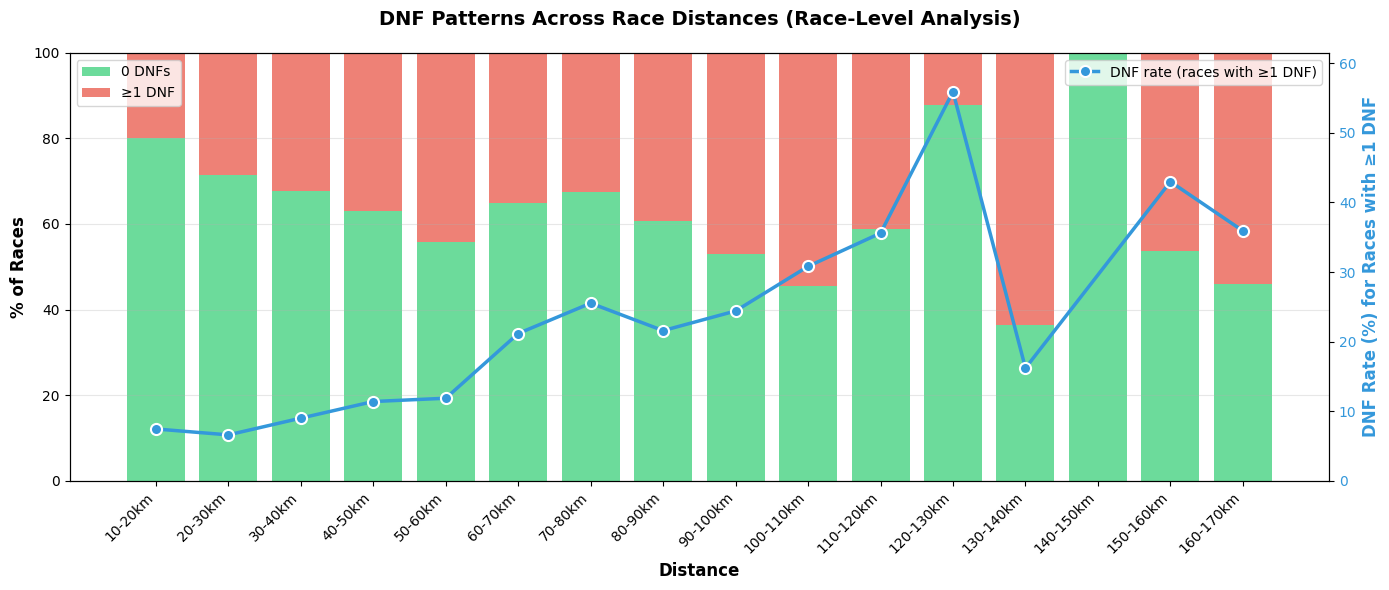

In [ ]:
# Bin races by distance (10km increments starting at 10km)
bins = np.arange(10, race_stats['distance_km'].max() + 10, 10)
bin_labels = [f"{int(b)}-{int(b+10)}km" for b in bins[:-1]]
race_stats['distance_bin'] = pd.cut(race_stats['distance_km'], bins=bins, labels=bin_labels, include_lowest=True)

# Compute metrics for each bin
# For races WITH DNFs only
reporting_races = race_stats[race_stats['has_dnf'] > 0]
reporting_bin_stats = reporting_races.groupby('distance_bin', observed=True).agg({
    'n_dnf': 'sum',
    'n_attempts': 'sum'
}).reset_index()
reporting_bin_stats['dnf_rate'] = 100 * reporting_bin_stats['n_dnf'] / reporting_bin_stats['n_attempts']

# For all races
bin_stats = race_stats.groupby('distance_bin', observed=True).agg({
    'has_dnf': ['count', 'sum'],  # count = total races, sum = races with DNFs
}).reset_index()
bin_stats.columns = ['distance_bin', 'n_races', 'n_races_with_dnfs']

# Merge DNF rate from reporting races
bin_stats = bin_stats.merge(reporting_bin_stats[['distance_bin', 'dnf_rate']], 
                             on='distance_bin', how='left')

# Calculate percentages
bin_stats['pct_zero_dnfs'] = 100 * (1 - bin_stats['n_races_with_dnfs'] / bin_stats['n_races'])
bin_stats['pct_with_dnfs'] = 100 * bin_stats['n_races_with_dnfs'] / bin_stats['n_races']

# Create visualization
fig, ax1 = plt.subplots(figsize=(14, 6))

# Stacked bar chart for zero vs non-zero DNFs
x = np.arange(len(bin_stats))
width = 0.8

ax1.bar(x, bin_stats['pct_zero_dnfs'], width, label='0 DNFs', color='#2ecc71', alpha=0.7)
ax1.bar(x, bin_stats['pct_with_dnfs'], width, bottom=bin_stats['pct_zero_dnfs'], 
        label='≥1 DNF', color='#e74c3c', alpha=0.7)

ax1.set_xlabel('Distance', fontsize=12, fontweight='bold')
ax1.set_ylabel('% of Races', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(bin_stats['distance_bin'], rotation=45, ha='right')
ax1.set_ylim(0, 100)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Add second y-axis for DNF rate
ax2 = ax1.twinx()
# Only plot where we have data
valid_mask = bin_stats['dnf_rate'].notna()
ax2.plot(x[valid_mask], bin_stats.loc[valid_mask, 'dnf_rate'], 'o-', 
         color='#3498db', linewidth=2.5, markersize=8, 
         label='DNF rate (races with ≥1 DNF)', 
         markeredgecolor='white', markeredgewidth=1.5)
ax2.set_ylabel('DNF Rate (%) for Races with ≥1 DNF', fontsize=12, fontweight='bold', color='#3498db')
ax2.tick_params(axis='y', labelcolor='#3498db')
ax2.set_ylim(0, max(bin_stats['dnf_rate'].max() * 1.1, 40))  # Auto-scale with minimum of 40%
ax2.legend(loc='upper right', fontsize=10)

plt.title('DNF Patterns Across Race Distances (Race-Level Analysis)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## Specification

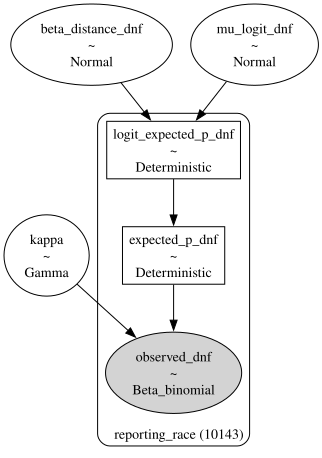

In [ ]:
# SIMPLER APPROACH: Learn μ, β, κ from clean data, compute p_reports as derived quantity
# Much faster than mixture model with 30K+ latent variables!

# Filter to ONLY races with observed DNFs for learning the distance-DNF relationship
reporting_races = race_stats[race_stats['has_dnf'] == 1].copy()
n_races_reporting = len(reporting_races)

# Prepare data for PyMC (race-level with LINEAR distance)
reference_distance = 50.0  # km (for centering)
centered_distance_reporting = reporting_races['distance_km'].values - reference_distance

with pm.Model(coords={'reporting_race': reporting_races['event_distance_id'].values}) as reporting_model:
    
    # ===== Learn distance-DNF relationship from reporting races ONLY =====
    # logit(p_dnf) = μ + β × (distance - 50km)
    # WEAKLY INFORMATIVE PRIORS: Allow data to dominate while staying in valid ranges
    mu_logit_dnf = pm.Normal('mu_logit_dnf', mu=0.0, sigma=5.0)  # Weak prior on intercept
    beta_distance_dnf = pm.Normal('beta_distance_dnf', mu=0.0, sigma=0.1)  # Weak prior on slope
    kappa = pm.Gamma('kappa', alpha=2, beta=0.1)  # Controls overdispersion
    
    # Expected DNF rate for reporting races
    logit_expected_p_dnf = pm.Deterministic(
        'logit_expected_p_dnf',
        mu_logit_dnf + beta_distance_dnf * centered_distance_reporting,
        dims='reporting_race'
    )
    expected_p_dnf = pm.Deterministic(
        'expected_p_dnf',
        pm.math.invlogit(logit_expected_p_dnf),
        dims='reporting_race'
    )
    
    # Beta-binomial parameters
    alpha = expected_p_dnf * kappa
    beta = (1 - expected_p_dnf) * kappa
    
    # Likelihood: Observed DNF counts (ONLY races with DNFs - clean training data)
    observed_dnf = pm.BetaBinomial(
        'observed_dnf',
        alpha=alpha,
        beta=beta,
        n=reporting_races['n_attempts'].values,
        observed=reporting_races['n_dnf'].values,
        dims='reporting_race'
    )

pm.model_to_graphviz(reporting_model)


## Inference

### MCMC Sampling

In [ ]:
model_m5_dnf_dir = '../data/cache/model_m5_dnf'
reporting_cache_file = f'{model_m5_dnf_dir}/reporting_trace.nc'

if os.path.exists(reporting_cache_file):
    print(f"Loading cached trace from {reporting_cache_file}")
    reporting_trace = az.from_netcdf(reporting_cache_file)
else:
    with reporting_model:
        reporting_trace = pm.sample(
            draws=2000,
            tune=2000,
            target_accept=0.95,
            return_inferencedata=True,
            random_seed=42
        )
    
    # Create directory if it doesn't exist
    os.makedirs(model_m5_dnf_dir, exist_ok=True)
    
    # Save trace
    reporting_trace.to_netcdf(reporting_cache_file)
    print(f"Saved trace to {reporting_cache_file}")

print(az.summary(reporting_trace, var_names=['mu_logit_dnf', 'beta_distance_dnf', 'kappa']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_logit_dnf, beta_distance_dnf, kappa]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 78 seconds.


Saved trace to models/model_m5_dnf/reporting_trace.nc
                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
mu_logit_dnf       -1.884  0.010  -1.904   -1.866      0.000    0.000   
beta_distance_dnf   0.014  0.000   0.014    0.014      0.000    0.000   
kappa              11.293  0.211  10.892   11.672      0.003    0.002   

                   ess_bulk  ess_tail  r_hat  
mu_logit_dnf         4596.0    4967.0    1.0  
beta_distance_dnf    4859.0    5239.0    1.0  
kappa                5009.0    5147.0    1.0  


### Traceplot

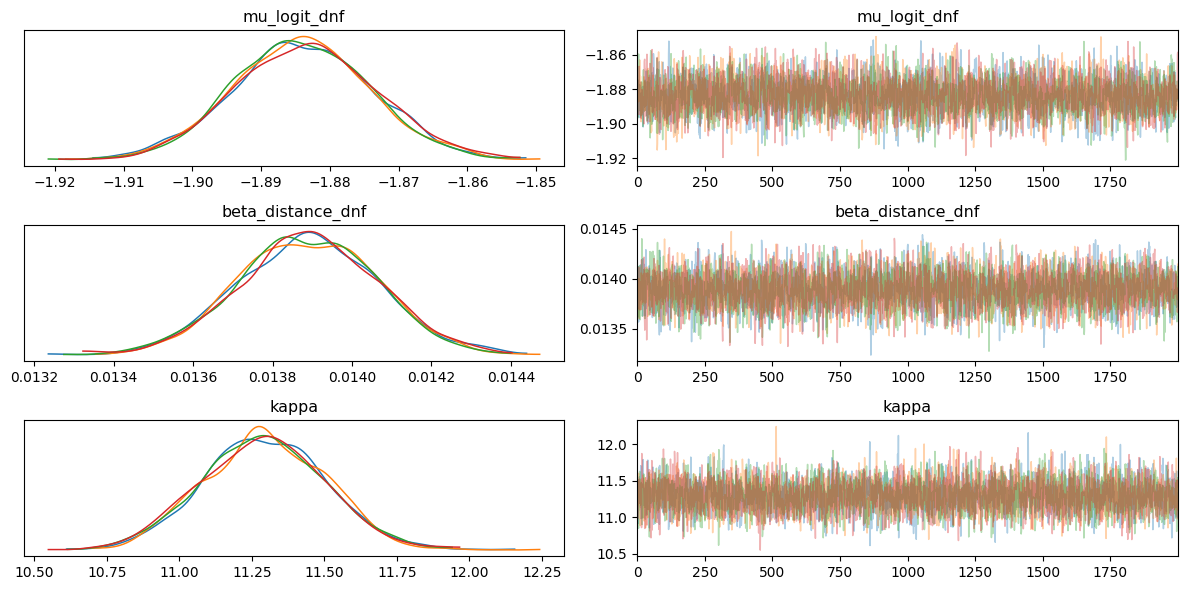

In [ ]:
az.plot_trace(reporting_trace, var_names=['mu_logit_dnf', 'beta_distance_dnf', 'kappa'], compact=False)
plt.tight_layout()
plt.show()

### Compute Reporting Probabilities

In [ ]:
# Compute P(0 DNFs | reporting) for races with zero observed DNFs

# For races that report DNFs, we know the expected DNF rate from the model.
# For races with 0 observed DNFs, we can compute how likely that is under the model.
# 
# P(0 DNFs | reporting, distance, n_attempts) comes from the beta-binomial
# 
# If this probability is very low, it suggests the race might not be reporting DNFs.
# We don't need a prior on P(reporting) - just the likelihood of the observed data.

# Extract posterior samples
mu_samples = reporting_trace.posterior['mu_logit_dnf'].values.flatten()
beta_samples = reporting_trace.posterior['beta_distance_dnf'].values.flatten()
kappa_samples = reporting_trace.posterior['kappa'].values.flatten()

n_samples = len(mu_samples)

# Get race data
race_distances = race_stats['distance_km'].values
n_attempts_all = race_stats['n_attempts'].values
dnf_counts_all = race_stats['n_dnf'].values

n_races = len(race_stats)

# Center distances for model
centered_distances_all = race_distances - reference_distance

# Initialize array to store P(0 DNFs | reporting) for each race
p_zero_dnfs_samples = np.zeros((n_samples, n_races))

# Only compute for races with 0 observed DNFs
zero_dnf_mask = (dnf_counts_all == 0)
zero_dnf_indices = np.where(zero_dnf_mask)[0]

# For each posterior sample, compute P(0 DNFs | reporting) for races with 0 DNFs
for i in range(n_samples):
    mu_i = mu_samples[i]
    beta_i = beta_samples[i]
    kappa_i = kappa_samples[i]
    
    # Expected p_dnf for races with 0 DNFs (distance-dependent)
    centered_distances_zero = centered_distances_all[zero_dnf_indices]
    logit_p_dnf = mu_i + beta_i * centered_distances_zero
    p_dnf = 1 / (1 + np.exp(-logit_p_dnf))
    
    # Beta-binomial parameters
    alpha = p_dnf * kappa_i
    beta_param = (1 - p_dnf) * kappa_i
    
    n_zero = n_attempts_all[zero_dnf_indices]
    
    # For n=1, use binomial: P(0 | 1 attempt) = 1 - p_dnf
    n_eq_1_mask = (n_zero == 1)
    p_zero_dnfs_samples[i, zero_dnf_indices[n_eq_1_mask]] = 1 - p_dnf[n_eq_1_mask]
    
    # For n > 1, use beta-binomial (vectorized)
    n_gt_1_mask = (n_zero > 1)
    if n_gt_1_mask.any():
        log_p_zero = (
            betaln(alpha[n_gt_1_mask], beta_param[n_gt_1_mask] + n_zero[n_gt_1_mask]) - 
            betaln(alpha[n_gt_1_mask], beta_param[n_gt_1_mask])
        )
        p_zero_dnfs_samples[i, zero_dnf_indices[n_gt_1_mask]] = np.exp(log_p_zero)

# Compute summary statistics across posterior samples
p_zero_dnfs_mean = p_zero_dnfs_samples.mean(axis=0)
p_zero_dnfs_std = p_zero_dnfs_samples.std(axis=0)

# Add to race_stats dataframe (only non-zero for races with 0 DNFs)
race_stats['p_zero_dnfs_if_reporting'] = p_zero_dnfs_mean
race_stats['p_zero_dnfs_std'] = p_zero_dnfs_std

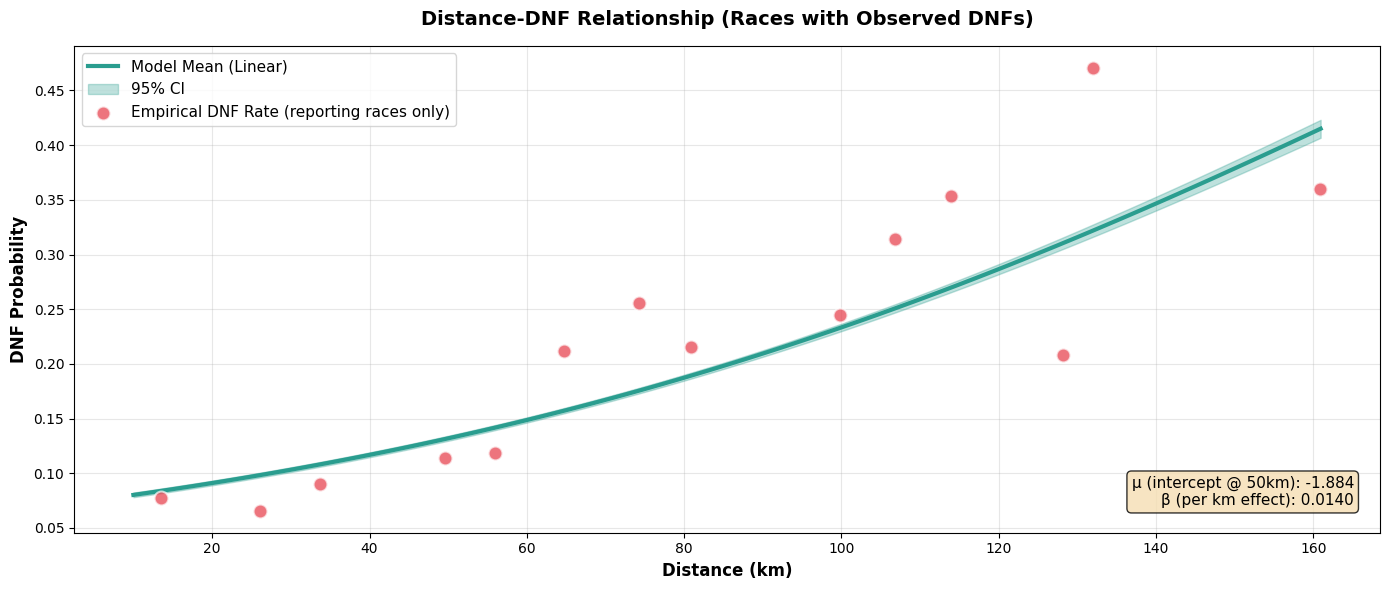


Parameter estimates (LINEAR model):
                    mean    sd  hdi_3%  hdi_97%
mu_logit_dnf      -1.884  0.01  -1.904   -1.866
beta_distance_dnf  0.014  0.00   0.014    0.014


In [ ]:
# Visualize the learned LINEAR distance-DNF relationship from the model

# Create a range of distances for visualization
distance_range = np.linspace(race_stats['distance_km'].min(), race_stats['distance_km'].max(), 100)
centered_distance_viz = distance_range - reference_distance

# Extract posterior samples for the parameters
mu_samples_viz = reporting_trace.posterior['mu_logit_dnf'].values.flatten()
beta_samples_viz = reporting_trace.posterior['beta_distance_dnf'].values.flatten()

# Compute predicted DNF probabilities for each distance (LINEAR model)
predicted_dnf_probs = np.zeros((len(mu_samples_viz), len(distance_range)))
for i in range(len(mu_samples_viz)):
    logit_p_dnf = mu_samples_viz[i] + beta_samples_viz[i] * centered_distance_viz
    predicted_dnf_probs[i, :] = 1 / (1 + np.exp(-logit_p_dnf))

# Compute mean and credible intervals
mean_dnf_prob = predicted_dnf_probs.mean(axis=0)
lower_ci = np.percentile(predicted_dnf_probs, 2.5, axis=0)
upper_ci = np.percentile(predicted_dnf_probs, 97.5, axis=0)

# Compute empirical DNF rates by distance bins for comparison
# Use ONLY races with observed DNFs (same as training data) for fair comparison
reporting_races_only = race_stats[race_stats['has_dnf'] > 0]
empirical_bins = pd.cut(reporting_races_only['distance_km'], bins=15)
empirical_stats = reporting_races_only.groupby(empirical_bins, observed=True).agg({
    'distance_km': 'mean',
    'n_dnf': 'sum',
    'n_attempts': 'sum'
}).reset_index(drop=True)
empirical_stats['dnf_rate'] = empirical_stats['n_dnf'] / empirical_stats['n_attempts']

# Create visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Plot model predictions
ax.plot(distance_range, mean_dnf_prob, color='#2A9D8F', linewidth=3, label='Model Mean (Linear)', zorder=3)
ax.fill_between(distance_range, lower_ci, upper_ci, color='#2A9D8F', alpha=0.3, label='95% CI', zorder=2)

# Plot empirical data points (only from reporting races)
ax.scatter(empirical_stats['distance_km'], empirical_stats['dnf_rate'], 
          s=100, color='#E63946', alpha=0.7, edgecolor='white', linewidth=1.5,
          label='Empirical DNF Rate (reporting races only)', zorder=4)

ax.set_xlabel('Distance (km)', fontsize=12, fontweight='bold')
ax.set_ylabel('DNF Probability', fontsize=12, fontweight='bold')
ax.set_title('Distance-DNF Relationship (Races with Observed DNFs)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

# Add parameter annotations
param_summary = az.summary(reporting_trace, var_names=['mu_logit_dnf', 'beta_distance_dnf'])
mu_mean = param_summary.loc['mu_logit_dnf', 'mean']
beta_mean = param_summary.loc['beta_distance_dnf', 'mean']

ax.text(0.98, 0.05, 
       f'μ (intercept @ 50km): {mu_mean:.3f}\nβ (per km effect): {beta_mean:.4f}',
       transform=ax.transAxes, fontsize=11, verticalalignment='bottom', horizontalalignment='right',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nParameter estimates (LINEAR model):")
print(param_summary[['mean', 'sd', 'hdi_3%', 'hdi_97%']])


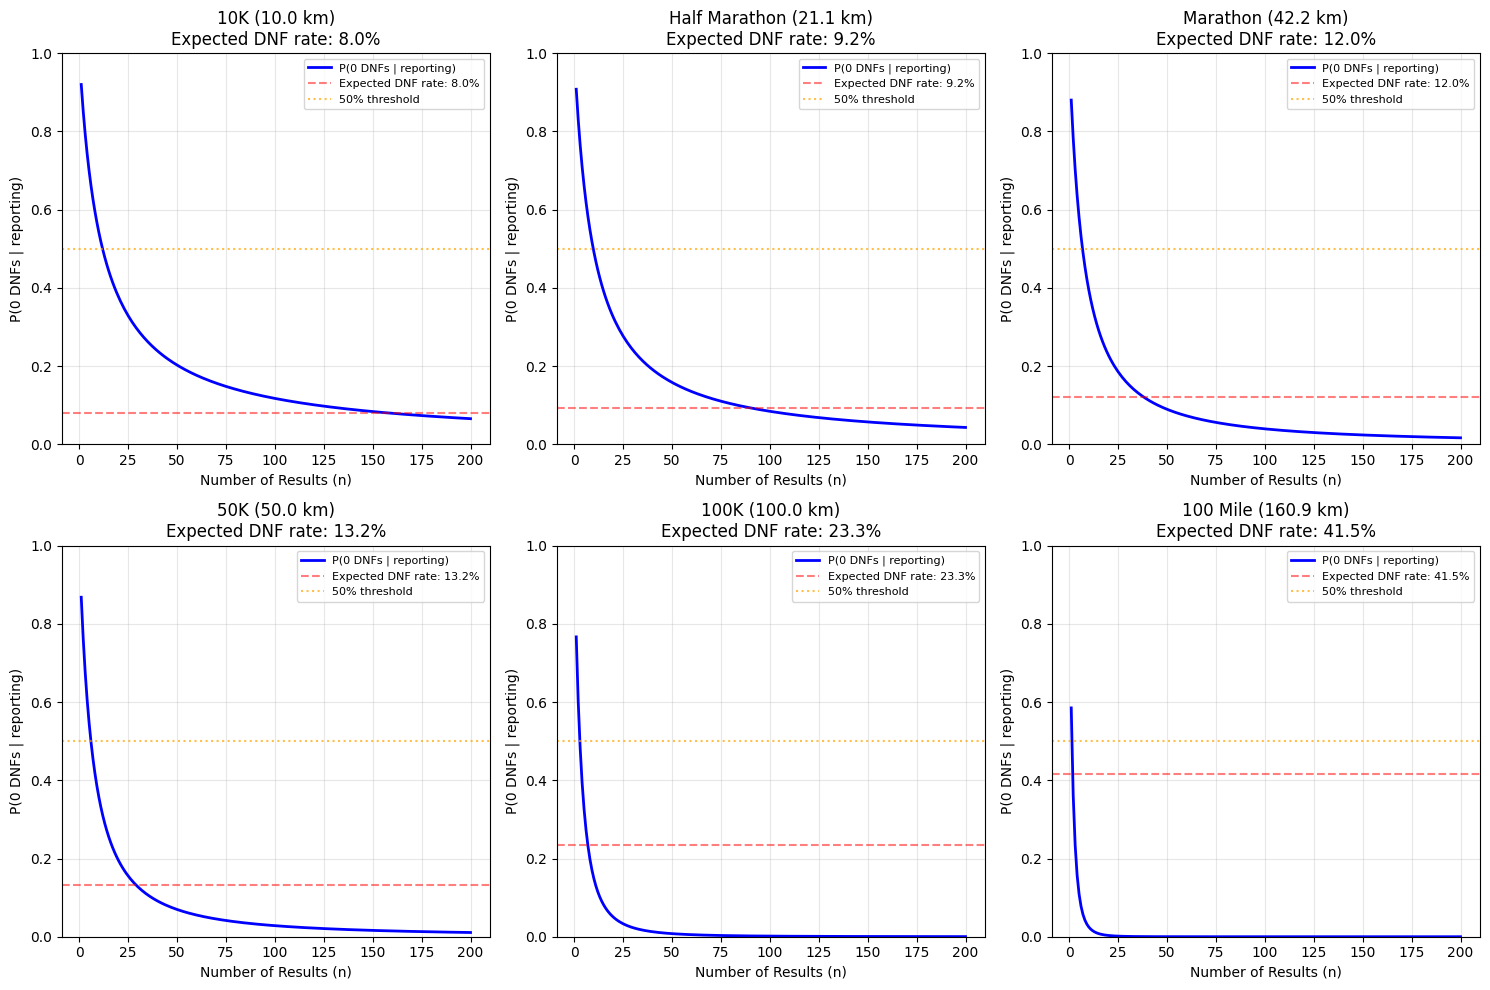

In [ ]:
# Diagnostic: How does P(0 DNFs | reporting) change with number of results?

# Show theoretical curves for standard race distances
# This shows: as we see more results without DNFs, how unlikely does that become
# under the model's learned DNF rate for each distance?

from scipy.special import betaln

# Use posterior means for visualization
mu_mean = reporting_trace.posterior['mu_logit_dnf'].mean().item()
beta_mean = reporting_trace.posterior['beta_distance_dnf'].mean().item()
kappa_mean = reporting_trace.posterior['kappa'].mean().item()

# Standard distances to visualize
standard_distances = [
    ('10K', 10.0),
    ('Half Marathon', 21.1),
    ('Marathon', 42.2),
    ('50K', 50.0),
    ('100K', 100.0),
    ('100 Mile', 160.9)
]

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Range of n_attempts to visualize
n_attempts_range = np.arange(1, 201)

for idx, (dist_name, dist_km) in enumerate(standard_distances):
    ax = axes[idx]
    
    # Compute expected p_dnf at this distance
    centered_dist = dist_km - reference_distance
    logit_p_dnf = mu_mean + beta_mean * centered_dist
    p_dnf_expected = 1 / (1 + np.exp(-logit_p_dnf))
    
    # Beta-binomial parameters
    alpha = p_dnf_expected * kappa_mean
    beta_param = (1 - p_dnf_expected) * kappa_mean
    
    # Compute P(0 DNFs | reporting) for each n
    p_zero_given_reporting = np.zeros(len(n_attempts_range))
    
    for i, n in enumerate(n_attempts_range):
        if n == 1:
            # Binomial for n=1
            p_zero_given_reporting[i] = 1 - p_dnf_expected
        else:
            # Beta-binomial for n > 1
            log_p_zero = betaln(alpha, beta_param + n) - betaln(alpha, beta_param)
            p_zero_given_reporting[i] = np.exp(log_p_zero)
    
    # Plot the curve
    ax.plot(n_attempts_range, p_zero_given_reporting, 'b-', linewidth=2, 
            label='P(0 DNFs | reporting)')
    
    # Add horizontal line at expected DNF rate for reference
    ax.axhline(y=p_dnf_expected, color='red', linestyle='--', alpha=0.5,
              label=f'Expected DNF rate: {p_dnf_expected:.1%}')
    
    # Add threshold line at 50%
    ax.axhline(y=0.5, color='orange', linestyle=':', alpha=0.7,
              label='50% threshold')
    
    # Formatting
    ax.set_xlabel('Number of Results (n)')
    ax.set_ylabel('P(0 DNFs | reporting)')
    ax.set_title(f'{dist_name} ({dist_km} km)\nExpected DNF rate: {p_dnf_expected:.1%}')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


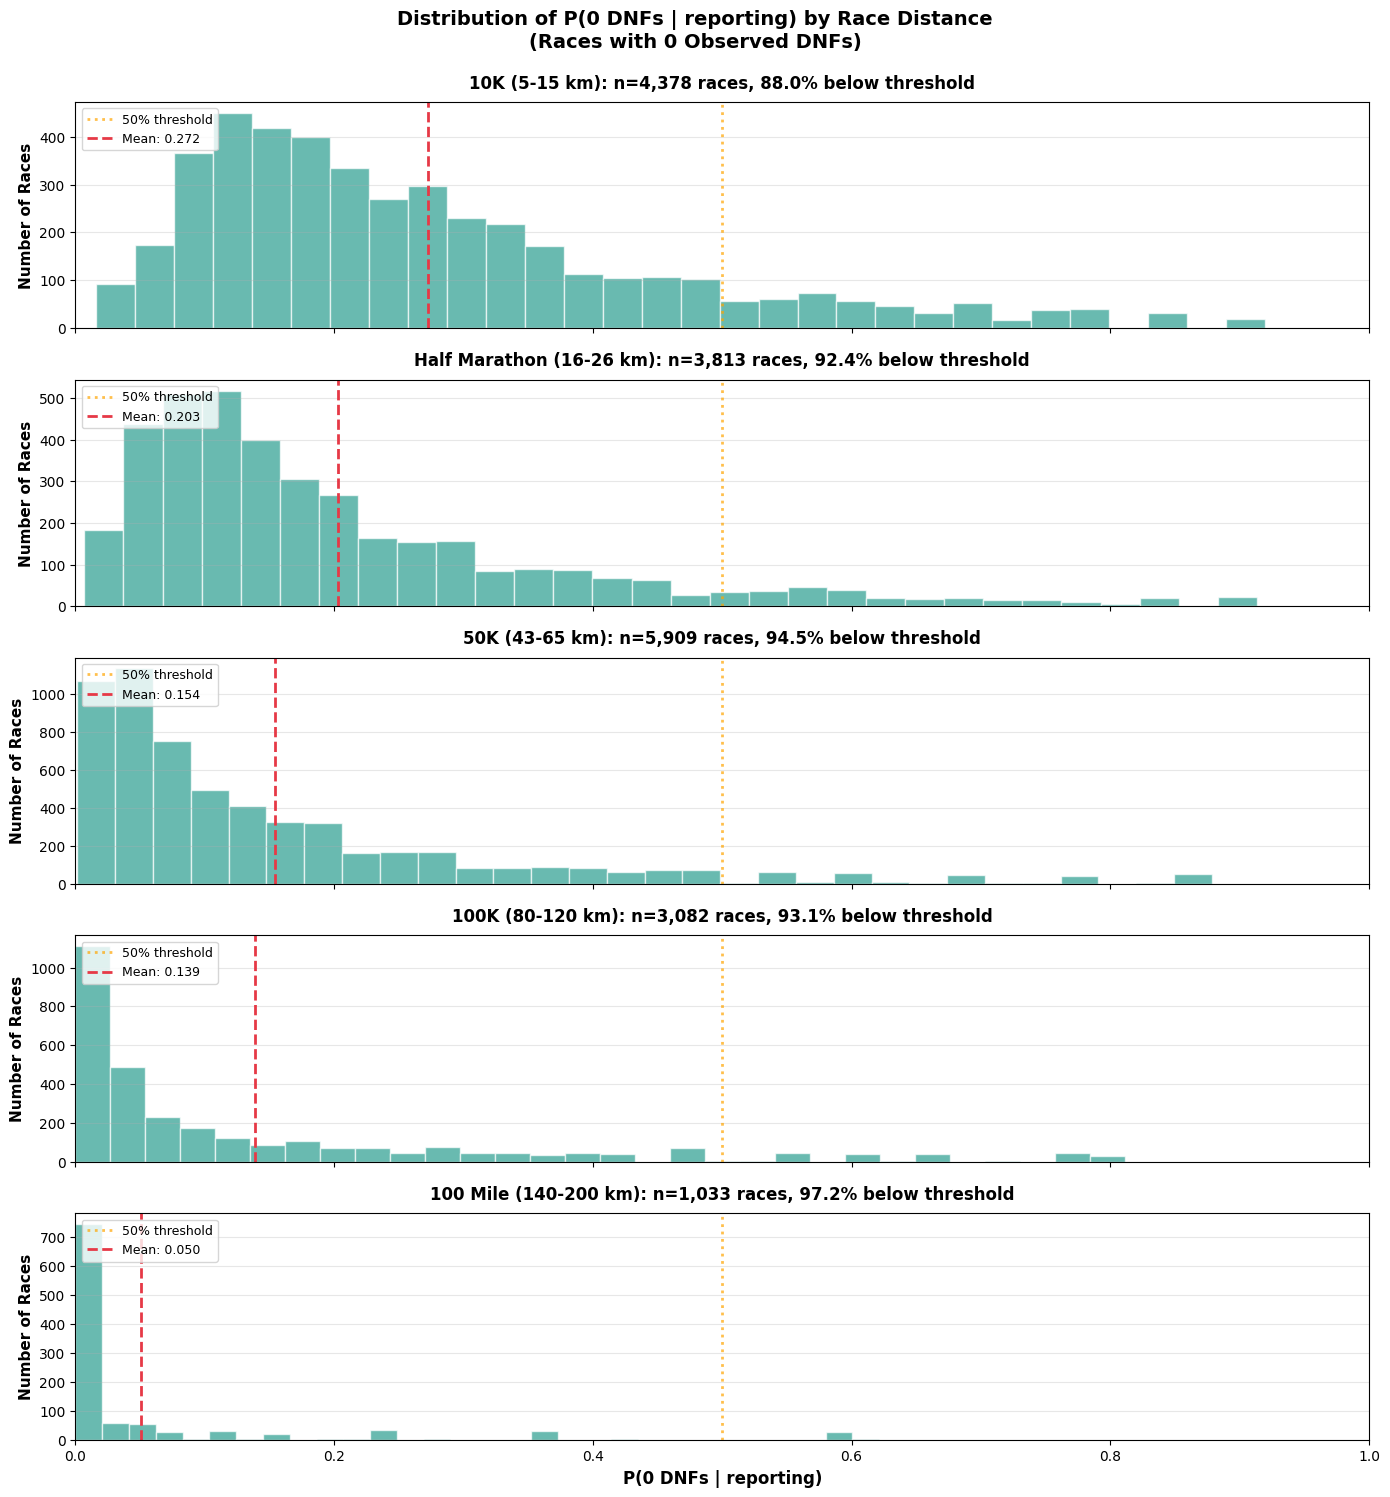


Summary by distance category:
Category        Range (km)      N Races    Mean P(0)    < 50%      < 10%      < 1%      
------------------------------------------------------------------------------------------
10K             5-15            4,378      0.272        3,853      549        0         
Half Marathon   16-26           3,813      0.203        3,522      1,164      12        
50K             43-65           5,909      0.154        5,584      3,135      208       
100K            80-120          3,082      0.139        2,870      1,961      606       
100 Mile        140-200         1,033      0.050        1,004      885        679       


In [ ]:
# Histogram of actual P(0 DNFs | reporting) for races with 0 observed DNFs
# Faceted by standard race distances

# Get races without any DNFs
races_without_dnf = race_stats[race_stats['n_dnf'] == 0].copy()

# Define standard race distances (matching the theoretical curves)
# Using ±5km windows around each standard distance
distance_categories = [
    ('10K', 10.0, 5.0, 15.0),
    ('Half Marathon', 21.1, 16.0, 26.0),
    ('50K', 50.0, 43.0, 65.0),
    ('100K', 100.0, 80.0, 120.0),
    ('100 Mile', 160.9, 140.0, 200.0)
]

# Assign distance category
def categorize_distance(dist_km):
    for cat_name, center, min_dist, max_dist in distance_categories:
        if min_dist <= dist_km < max_dist:
            return cat_name
    return None

races_without_dnf['distance_category'] = races_without_dnf['distance_km'].apply(categorize_distance)
races_without_dnf = races_without_dnf[races_without_dnf['distance_category'].notna()]

# Create vertical faceted plot
fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)

for idx, (cat_name, center, min_dist, max_dist) in enumerate(distance_categories):
    ax = axes[idx]
    
    # Filter data for this category
    cat_data = races_without_dnf[races_without_dnf['distance_category'] == cat_name]
    
    if len(cat_data) > 0:
        p_zero_cat = cat_data['p_zero_dnfs_if_reporting'].values
        
        # Histogram
        ax.hist(p_zero_cat, bins=30, edgecolor='white', alpha=0.7, color='#2A9D8F')
        
        # Add vertical line at 50% threshold
        ax.axvline(x=0.5, color='orange', linestyle=':', linewidth=2, alpha=0.7,
                   label='50% threshold')
        
        # Add mean line
        ax.axvline(x=p_zero_cat.mean(), color='#E63946', linestyle='--', linewidth=2,
                   label=f'Mean: {p_zero_cat.mean():.3f}')
        
        # Stats
        below_threshold = (p_zero_cat < 0.5).sum()
        pct_below = 100 * below_threshold / len(p_zero_cat)
        
        # Formatting
        ax.set_ylabel('Number of Races', fontsize=11, fontweight='bold')
        ax.set_title(f'{cat_name} ({min_dist:.0f}-{max_dist:.0f} km): n={len(cat_data):,} races, {pct_below:.1f}% below threshold', 
                     fontsize=12, fontweight='bold', pad=10)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xlim(0, 1)
        ax.legend(fontsize=9, loc='upper left')
    else:
        ax.text(0.5, 0.5, f'No data for {cat_name}', 
                ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlim(0, 1)

# Common x-label
axes[-1].set_xlabel('P(0 DNFs | reporting)', fontsize=12, fontweight='bold')

plt.suptitle('Distribution of P(0 DNFs | reporting) by Race Distance\n(Races with 0 Observed DNFs)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print summary by category
print("\nSummary by distance category:")
print(f"{'Category':<15} {'Range (km)':<15} {'N Races':<10} {'Mean P(0)':<12} {'< 50%':<10} {'< 10%':<10} {'< 1%':<10}")
print("-" * 90)
for cat_name, center, min_dist, max_dist in distance_categories:
    cat_data = races_without_dnf[races_without_dnf['distance_category'] == cat_name]
    if len(cat_data) > 0:
        p_zero_cat = cat_data['p_zero_dnfs_if_reporting'].values
        mean_p = p_zero_cat.mean()
        below_50 = (p_zero_cat < 0.5).sum()
        below_10 = (p_zero_cat < 0.1).sum()
        below_1 = (p_zero_cat < 0.01).sum()
        range_str = f"{min_dist:.0f}-{max_dist:.0f}"
        print(f"{cat_name:<15} {range_str:<15} {len(cat_data):<10,} {mean_p:<12.3f} {below_50:<10,} {below_10:<10,} {below_1:<10,}")
